In [1]:
# ============================================================
# Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn.model_selection as skm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.patches import Rectangle, FancyArrowPatch
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from pygam import s, l, f, LinearGAM
from tqdm.auto import tqdm

Dataset shape: (5455, 46)

Rows available for plots: 5003
            BMXBMI     LBXHSCRP   phq9_score
count  5003.000000  5003.000000  5003.000000
mean     29.650130     3.768549     4.017589
std       7.179966     7.188050     4.687569
min      15.000000     0.110000     0.000000
25%      24.600000     0.790000     1.000000
50%      28.400000     1.770000     2.000000
75%      33.400000     4.080000     6.000000
max      69.900000   110.980000    26.000000


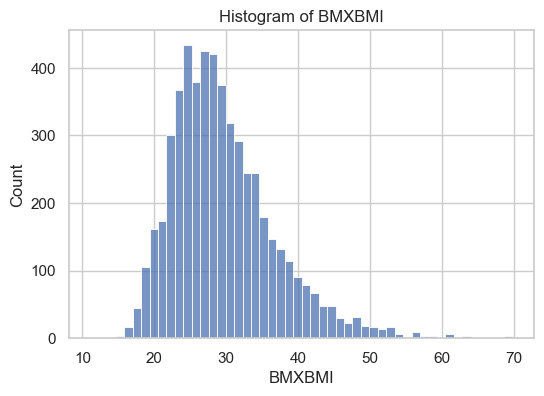

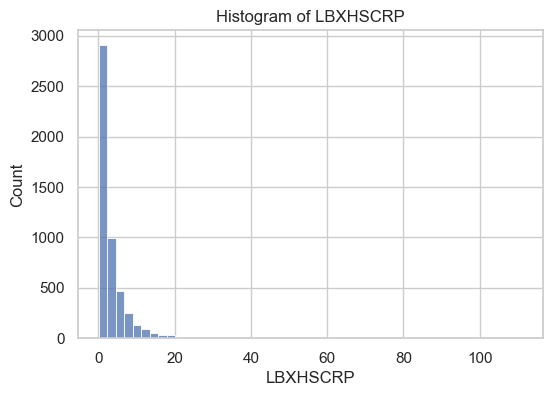

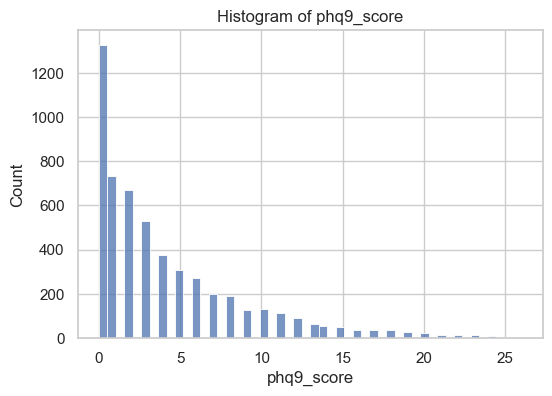

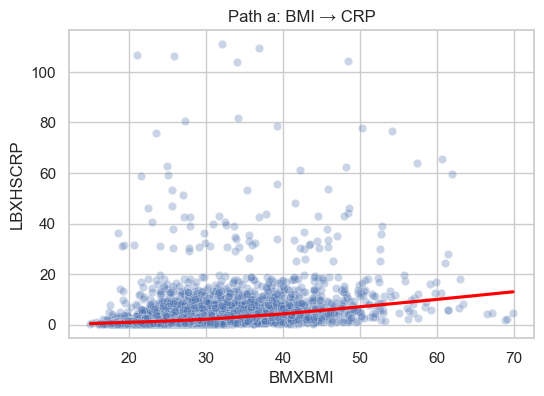

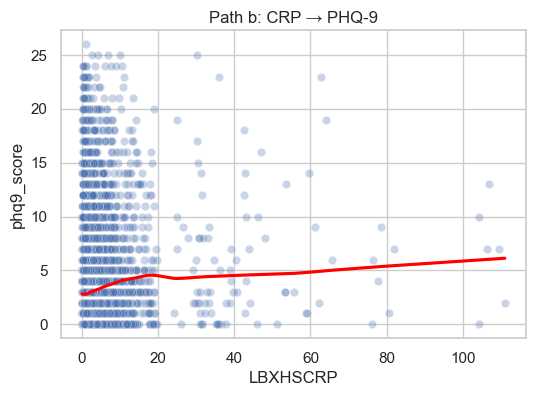

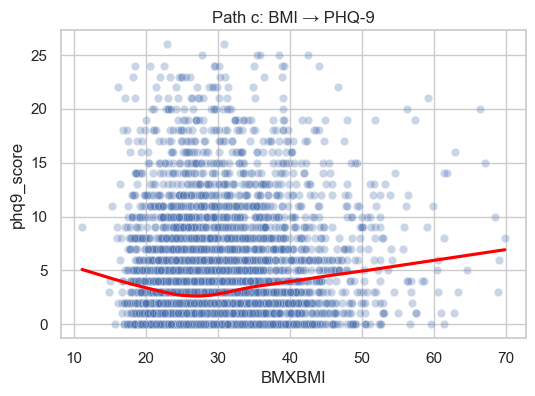


Variable: BMXBMI
Q1 = 24.5
Q3 = 33.4
IQR = 8.899999999999999
Lower extreme cutoff = -2.1999999999999957
Upper extreme cutoff = 60.099999999999994
Extreme outliers detected = 18


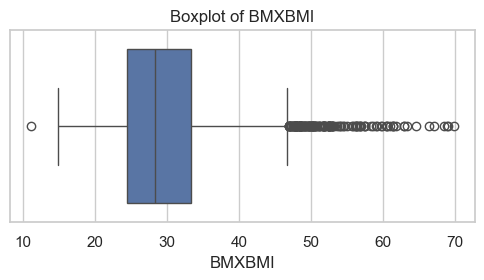


Variable: LBXHSCRP
Q1 = 0.8
Q3 = 4.1075
IQR = 3.3075
Lower extreme cutoff = -9.122499999999999
Upper extreme cutoff = 14.03
Extreme outliers detected = 188


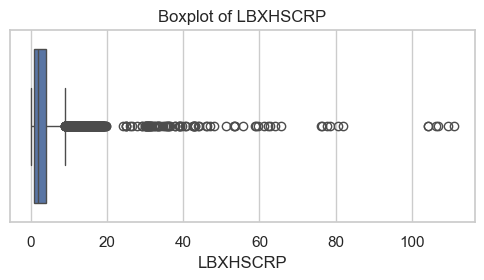


Variable: phq9_score
Q1 = 1.0
Q3 = 6.0
IQR = 5.0
Lower extreme cutoff = -14.0
Upper extreme cutoff = 21.0
Extreme outliers detected = 42


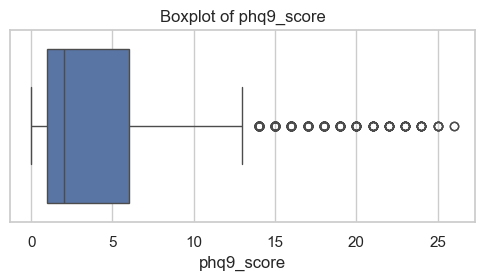

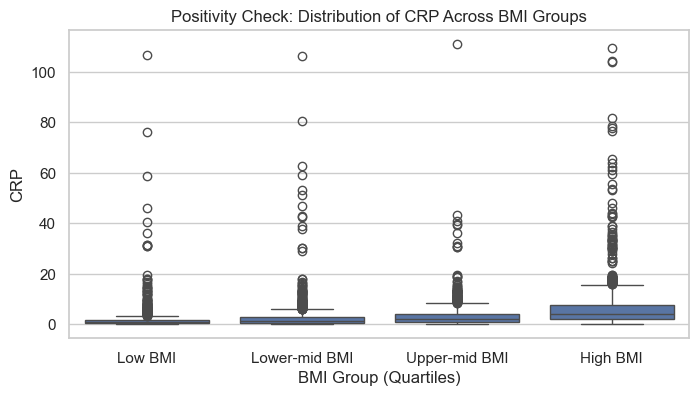


CRP Summary Within Each BMI Group:
                count      mean        std   min   25%    50%     75%     max
BMI_group                                                                    
Low BMI        1273.0  1.921218   5.195063  0.11  0.45  0.820  1.6800  106.78
Lower-mid BMI  1246.0  2.816950   6.142848  0.11  0.70  1.330  2.8800  106.25
Upper-mid BMI  1246.0  3.436701   5.115379  0.11  1.05  2.085  4.0450  110.98
High BMI       1238.0  6.959847  10.106083  0.19  2.25  4.195  7.6575  109.34


C:\Users\chris\AppData\Local\Temp\ipykernel_25016\3542245211.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pos_df.groupby("BMI_group")[CRP].describe())


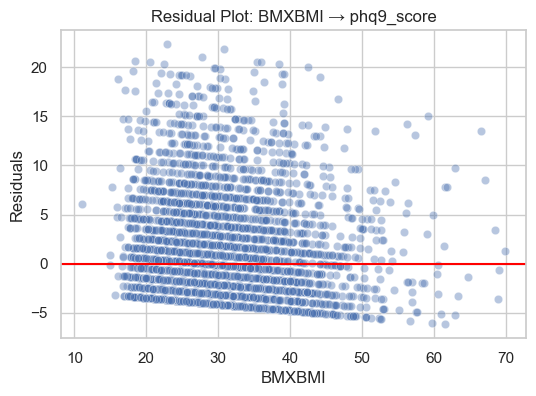

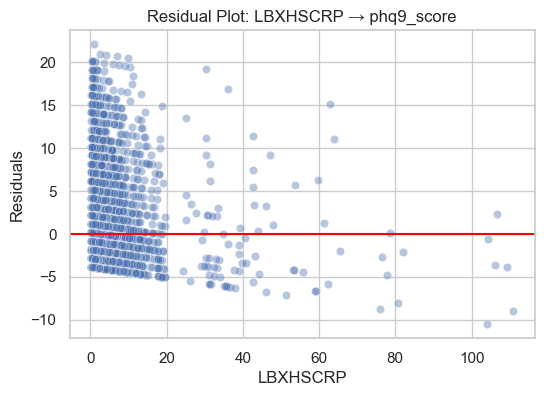


Sample size: 5003
Cook's distance threshold: 0.0007995202878273036
Influential points detected: 276


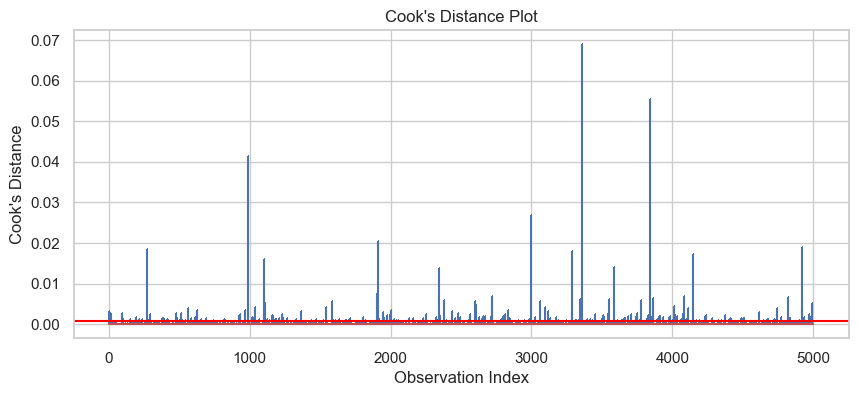


Variable types:
age                            int64
gender                        object
race_ethnicity                 int64
income_poverty_ratio         float64
cigarettes_per_day           float64
vigorous_activity_minutes    float64
moderate_activity_minutes    float64
sleep_avg                    float64
dtype: object

Summary statistics:
               age  race_ethnicity  income_poverty_ratio  cigarettes_per_day  \
count  5455.000000     5455.000000           4797.000000          151.000000   
mean     52.146288        3.285243              2.989562           12.364238   
std      18.189753        1.369836              1.656215            8.668320   
min      18.000000        1.000000              0.000000            0.000000   
25%      37.000000        3.000000              1.480000            4.000000   
50%      56.000000        3.000000              2.940000           12.000000   
75%      67.000000        3.000000              5.000000           20.000000   
max      80.

In [2]:
# ============================================================
##EDA for data overview
# ============================================================



sns.set(style="whitegrid")

# ============================================================
# LOAD DATA
# ============================================================

# This should function as long as the nhanes data file is located in the
# same folder as the code file. If not, then the file name here should be
# changed to the filepath of the dataset.

NHdata_OG = pd.read_csv('nhanes_data_merged.csv')
#print(NHdata.dtypes)

df = NHdata_OG.copy()

print("Dataset shape:", df.shape)

# Key variables
BMI = "BMXBMI"
CRP = "LBXHSCRP"
PHQ = "phq9_score"

# ============================================================
# BASIC SUMMARY STATISTICS
# ============================================================

core_df = df[[BMI, CRP, PHQ]].apply(pd.to_numeric, errors="coerce").dropna()

print("\nRows available for plots:", len(core_df))
print(core_df.describe())

# ============================================================
# HISTOGRAMS (Distribution Checks)
# ============================================================

variables = [BMI, CRP, PHQ]

for var in variables:
    
    plt.figure(figsize=(6,4))
    sns.histplot(df[var], bins=50)
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.show()

# ============================================================
# SCATTERPLOTS WITH LOWESS (Functional Form Check)
# ============================================================

pairs = [
    (BMI, CRP, "Path a: BMI → CRP"),
    (CRP, PHQ, "Path b: CRP → PHQ-9"),
    (BMI, PHQ, "Path c: BMI → PHQ-9")
]

for x, y, title in pairs:
    
    temp = df[[x,y]].apply(pd.to_numeric, errors="coerce").dropna()
    
    plt.figure(figsize=(6,4))
    
    sns.scatterplot(data=temp, x=x, y=y, alpha=0.3)
    
    sns.regplot(
        data=temp,
        x=x,
        y=y,
        scatter=False,
        lowess=True,
        line_kws={"color":"red"}
    )
    
    plt.title(title)
    plt.show()

# ============================================================
# EXTREME OUTLIERS (3*IQR RULE)
# ============================================================

for var in variables:

    data = df[var].dropna()

    Q1 = data.quantile(.25)
    Q3 = data.quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 3*IQR
    upper = Q3 + 3*IQR

    extreme = data[(data < lower) | (data > upper)]

    print("\n========================")
    print("Variable:", var)
    print("Q1 =", Q1)
    print("Q3 =", Q3)
    print("IQR =", IQR)
    print("Lower extreme cutoff =", lower)
    print("Upper extreme cutoff =", upper)
    print("Extreme outliers detected =", len(extreme))

    plt.figure(figsize=(6,2.5))
    sns.boxplot(x=data)
    plt.title(f"Boxplot of {var}")
    plt.show()

# ============================================================
# POSITIVITY CHECK
# CRP distribution across BMI quartiles
# ============================================================

pos_df = df[[BMI,CRP]].apply(pd.to_numeric, errors="coerce").dropna()

pos_df["BMI_group"] = pd.qcut(
    pos_df[BMI],
    q=4,
    labels=["Low BMI","Lower-mid BMI","Upper-mid BMI","High BMI"]
)

plt.figure(figsize=(8,4))

sns.boxplot(
    data=pos_df,
    x="BMI_group",
    y=CRP
)

plt.title("Positivity Check: Distribution of CRP Across BMI Groups")
plt.xlabel("BMI Group (Quartiles)")
plt.ylabel("CRP")
plt.show()

print("\nCRP Summary Within Each BMI Group:")
print(pos_df.groupby("BMI_group")[CRP].describe())

# ============================================================
# LINEARITY CHECK (Residual Plots)
# ============================================================

def residual_plot(xvar, yvar):

    temp = df[[xvar,yvar]].apply(pd.to_numeric, errors="coerce").dropna()

    X = sm.add_constant(temp[xvar])
    y = temp[yvar]

    model = sm.OLS(y, X).fit()

    residuals = model.resid

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=temp[xvar], y=residuals, alpha=.4)
    plt.axhline(0,color="red")
    plt.xlabel(xvar)
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot: {xvar} → {yvar}")
    plt.show()

residual_plot(BMI, PHQ)
residual_plot(CRP, PHQ)

# ============================================================
# COOK'S DISTANCE (Influential Observations)
# ============================================================

temp = df[[BMI,CRP,PHQ]].apply(pd.to_numeric, errors="coerce").dropna()

X = sm.add_constant(temp[[BMI,CRP]])
y = temp[PHQ]

model = sm.OLS(y,X).fit()

influence = model.get_influence()
cooks = influence.cooks_distance[0]

threshold = 4/len(temp)

print("\nSample size:",len(temp))
print("Cook's distance threshold:",threshold)

print("Influential points detected:",
      np.sum(cooks>threshold))

plt.figure(figsize=(10,4))

plt.stem(cooks, markerfmt=",")

plt.axhline(threshold,color="red")

plt.title("Cook's Distance Plot")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")

plt.show()

# ============================================================
# COVARIATE EDA
# ============================================================

covariates = [
    "age",
    "gender",
    "race_ethnicity",
    "income_poverty_ratio",
    "cigarettes_per_day",
    "vigorous_activity_minutes",
    "moderate_activity_minutes",
    "sleep_avg"
]

print("\nVariable types:")
print(df[covariates].dtypes)

print("\nSummary statistics:")
print(df[covariates].describe())

# ============================================================
# MULTICOLLINEARITY (VIF)
# ============================================================

vif_vars = [
    BMI,
    CRP,
    "age",
    "income_poverty_ratio",
    "vigorous_activity_minutes",
    "sleep_avg"
]

vif_df = df[vif_vars].apply(pd.to_numeric, errors="coerce").dropna()

X = sm.add_constant(vif_df)

vif_table = pd.DataFrame()
vif_table["Variable"] = X.columns
vif_table["VIF"] = [
    variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]

print("\nSample size used for VIF:",len(vif_df))
print(vif_table)

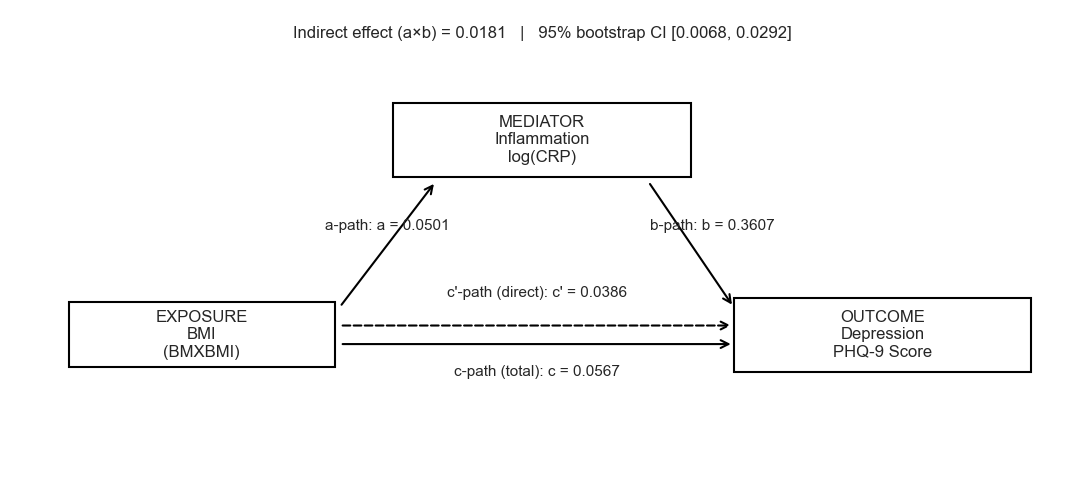

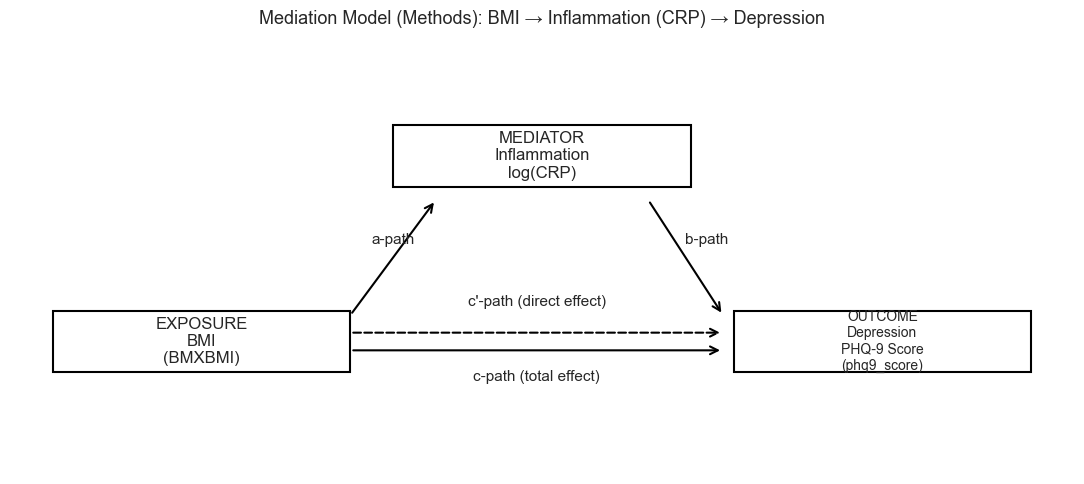

In [3]:
##Mediation Path Model code

# -------------------------
# Fill in coefficients
# -------------------------
a = 0.0501
b = 0.3607
c = 0.0567
c_prime = 0.0386
ab = a * b  # 0.0181

# Optional bootstrap CI for indirect effect
ci_low = 0.006785
ci_high = 0.029185

# -------------------------
# Helper functions
# -------------------------
def add_box(ax, center, text, width=0.26, height=0.13, fontsize=12):
    """Draw a white box with black border and centered text."""
    x, y = center
    rect = Rectangle(
        (x - width/2, y - height/2),
        width, height,
        facecolor="white", edgecolor="black", linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)
    return rect

def add_arrow(ax, start, end, label, linestyle="-", label_offset=(0, 0), fontsize=11):
    """Draw an arrow from start to end and place a label near its midpoint."""
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="->",
        mutation_scale=14,
        linewidth=1.5,
        linestyle=linestyle,
        color="black"
    )
    ax.add_patch(arrow)

    mx = (start[0] + end[0]) / 2 + label_offset[0]
    my = (start[1] + end[1]) / 2 + label_offset[1]
    ax.text(mx, my, label, ha="center", va="center", fontsize=fontsize)

# -------------------------
# Layout 
# -------------------------
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Node centers
exposure = (0.18, 0.30)
mediator = (0.50, 0.72)
outcome  = (0.82, 0.30)

# Draw boxes
add_box(ax, mediator, "MEDIATOR\nInflammation\nlog(CRP)", width=0.28, height=0.16, fontsize=12)
add_box(ax, exposure, "EXPOSURE\nBMI\n(BMXBMI)", width=0.25, height=0.14, fontsize=12)
add_box(ax, outcome,  "OUTCOME\nDepression\nPHQ-9 Score", width=0.28, height=0.16, fontsize=12)

# Draw paths (solid)
add_arrow(
    ax,
    start=(exposure[0] + 0.13, exposure[1] + 0.06),
    end=(mediator[0] - 0.10, mediator[1] - 0.09),
    label=f"a-path: a = {a:.4f}",
    linestyle="-",
    label_offset=(0.00, 0.04)
)

add_arrow(
    ax,
    start=(mediator[0] + 0.10, mediator[1] - 0.09),
    end=(outcome[0] - 0.14, outcome[1] + 0.06),
    label=f"b-path: b = {b:.4f}",
    linestyle="-",
    label_offset=(0.02, 0.04)
)

# Total effect c-path (solid, bottom)
add_arrow(
    ax,
    start=(exposure[0] + 0.13, exposure[1] - 0.02),
    end=(outcome[0] - 0.14, outcome[1] - 0.02),
    label=f"c-path (total): c = {c:.4f}",
    linestyle="-",
    label_offset=(0.00, -0.06)
)

# Direct effect c' (dashed, middle)
add_arrow(
    ax,
    start=(exposure[0] + 0.13, exposure[1] + 0.02),
    end=(outcome[0] - 0.14, outcome[1] + 0.02),
    label=f"c'-path (direct): c' = {c_prime:.4f}",
    linestyle="--",
    label_offset=(0.00, 0.07)
)

# Indirect effect annotation (clean, like papers)
ax.text(
    0.50, 0.95,
    f"Indirect effect (a×b) = {ab:.4f}   |   95% bootstrap CI [{ci_low:.4f}, {ci_high:.4f}]",
    ha="center", va="center", fontsize=12
)

plt.tight_layout()
plt.show()



####
#Diagram without numbers for methods section so results wont be revealed too early



def add_box(ax, center, text, width=0.28, height=0.14, fontsize=12):
    x, y = center
    rect = Rectangle(
        (x - width/2, y - height/2),
        width, height,
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)

def add_arrow(ax, start, end, label, linestyle="-", label_offset=(0,0), fontsize=11):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="->",
        mutation_scale=14,
        linewidth=1.5,
        linestyle=linestyle,
        color="black"
    )
    ax.add_patch(arrow)

    mx = (start[0] + end[0]) / 2 + label_offset[0]
    my = (start[1] + end[1]) / 2 + label_offset[1]
    ax.text(mx, my, label, ha="center", va="center", fontsize=fontsize)

# ---- Figure ----
fig, ax = plt.subplots(figsize=(11,5))
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.axis("off")

# Node locations
exposure = (0.18,0.30)
mediator = (0.50,0.72)
outcome  = (0.82,0.30)

# Boxes
add_box(ax, exposure,
        "EXPOSURE\nBMI\n(BMXBMI)",
        fontsize=12)

add_box(ax, mediator,
        "MEDIATOR\nInflammation\nlog(CRP)",
        fontsize=12)

# Smaller text for outcome so it fits better
add_box(ax, outcome,
        "OUTCOME\nDepression\nPHQ-9 Score\n(phq9_score)",
        fontsize=10)

# Arrows
add_arrow(ax,
          (exposure[0]+0.14, exposure[1]+0.06),
          (mediator[0]-0.10, mediator[1]-0.10),
          "a-path",
          label_offset=(0,0.04))

add_arrow(ax,
          (mediator[0]+0.10, mediator[1]-0.10),
          (outcome[0]-0.15, outcome[1]+0.06),
          "b-path",
          label_offset=(0.02,0.04))

add_arrow(ax,
          (exposure[0]+0.14, exposure[1]-0.02),
          (outcome[0]-0.15, outcome[1]-0.02),
          "c-path (total effect)",
          label_offset=(0,-0.06))

add_arrow(ax,
          (exposure[0]+0.14, exposure[1]+0.02),
          (outcome[0]-0.15, outcome[1]+0.02),
          "c'-path (direct effect)",
          linestyle="--",
          label_offset=(0,0.07))

plt.title("Mediation Model (Methods): BMI → Inflammation (CRP) → Depression", fontsize=13)
plt.tight_layout()

plt.savefig("mediation_methods_diagram.png", dpi=300, bbox_inches="tight")
plt.show()



TOTAL EFFECT model (c path):
                            OLS Regression Results                            
Dep. Variable:             phq9_score   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     40.98
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.74e-85
Time:                        18:16:23   Log-Likelihood:                -12641.
No. Observations:                4343   AIC:                         2.531e+04
Df Residuals:                    4331   BIC:                         2.538e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

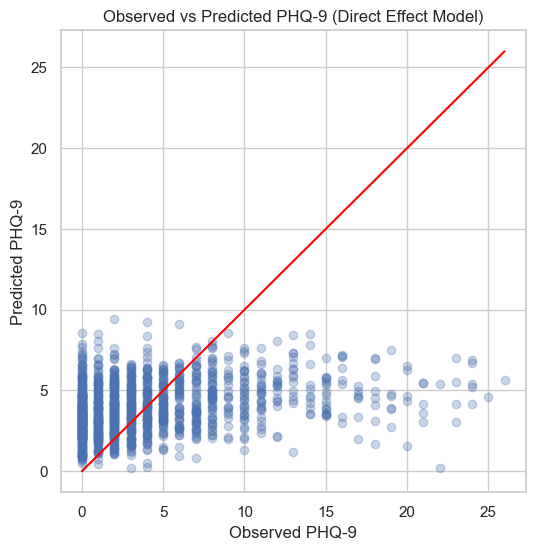

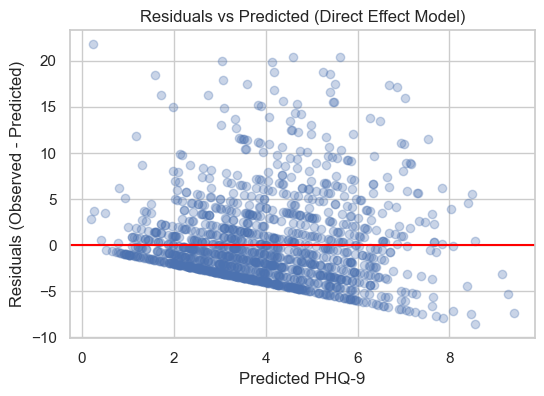

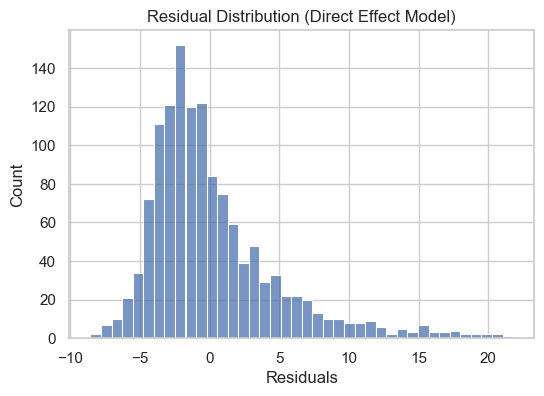


--- Overfit/Underfit Check: TOTAL model ---
Train R^2=0.110 vs Test R^2=0.083
Train RMSE=4.367 vs Test RMSE=4.637
Interpretation: No strong evidence of overfitting; performance is similar across train/test.

--- Overfit/Underfit Check: DIRECT model ---
Train R^2=0.114 vs Test R^2=0.082
Train RMSE=4.357 vs Test RMSE=4.640
Interpretation: No strong evidence of overfitting; performance is similar across train/test.


In [4]:
##Method 1: Linear regression to estimate the direct and total effects of BMI on depression severity as well as the relationship between BMI and CRP. 
##Includes constructing the mediation model paths.
#create model going forwards - start with intercept and add variables one by one to see what affects variance BIC or AIC terms to look up



BMI = "BMXBMI"
CRP = "LBXHSCRP"
PHQ = "phq9_score"

# Pick covariates you actually want in the adjusted models
covars = [
    "age",
    "income_poverty_ratio",
    "sleep_avg",
    "vigorous_activity_minutes",
    # optionally add:
    # "cigarettes_per_day",
    # "moderate_activity_minutes",
    # plus categorical vars as C(gender), C(race_ethnicity) if they’re coded cleanly
]

# Build analysis df
use_cols = [BMI, CRP, PHQ] + covars + ["gender", "race_ethnicity"]
d = df[use_cols].copy()

# Numeric conversion for continuous vars
for c in [BMI, CRP, PHQ] + covars:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# Transform CRP (helps a LOT)
d["logCRP"] = np.log1p(d[CRP])

# Optional nonlinear BMI term (sensitivity)
d["BMI2"] = d[BMI]**2

# Drop missing for models
d_model = d.dropna(subset=[BMI, "logCRP", PHQ] + covars)

# -------------------------
# TOTAL EFFECT (c path)
# -------------------------
formula_total = f"{PHQ} ~ {BMI} + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
m_total = smf.ols(formula_total, data=d_model).fit(cov_type="HC3")

# -------------------------
# MEDIATOR MODEL (a path)
# -------------------------
formula_a = f"logCRP ~ {BMI} + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
m_a = smf.ols(formula_a, data=d_model).fit(cov_type="HC3")

# -------------------------
# DIRECT EFFECT (c') + b path
# -------------------------
formula_direct = f"{PHQ} ~ {BMI} + logCRP + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
m_direct = smf.ols(formula_direct, data=d_model).fit(cov_type="HC3")

print("\nTOTAL EFFECT model (c path):")
print(m_total.summary())

print("\nMEDIATOR model (a path):")
print(m_a.summary())

print("\nDIRECT EFFECT model (c') + b path:")
print(m_direct.summary())

# Effect estimates (on logCRP scale)
a_hat = m_a.params[BMI]
b_hat = m_direct.params["logCRP"]
indirect_ab = a_hat * b_hat
direct_cprime = m_direct.params[BMI]
total_c = m_total.params[BMI]

print("\n--- Effects (point estimates) ---")
print("a (BMI -> logCRP):", a_hat)
print("b (logCRP -> PHQ | BMI):", b_hat)
print("Indirect (a*b):", indirect_ab)
print("Direct (c'):", direct_cprime)
print("Total (c):", total_c)

# -------------------------
# Optional sensitivity: quadratic BMI term
# -------------------------
formula_total_quad = f"{PHQ} ~ {BMI} + BMI2 + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
m_total_quad = smf.ols(formula_total_quad, data=d_model).fit(cov_type="HC3")

print("\nCompare linear vs quadratic total-effect model:")
print("Linear AIC/BIC:", m_total.aic, m_total.bic)
print("Quadratic AIC/BIC:", m_total_quad.aic, m_total_quad.bic)

####Prediction Validation Metrics



# Train test split
train, test = train_test_split(d_model, test_size=0.3, random_state=42)

# Refit model on training
m_train = smf.ols(formula_direct, data=train).fit()

# Predictions
pred = m_train.predict(test)

y_true = test["phq9_score"]

mse = mean_squared_error(y_true, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R^2:", r2)

# =========================
# Model 1 Results Code
# Produces:
# 1) Model comparison table
# 2) Validation metrics (Train/Test MSE, RMSE, R^2)
# 3) Prediction visualizations
# 4) Overfitting/underfitting check (train vs test)
# =========================


sns.set(style="whitegrid")

BMI = "BMXBMI"
CRP = "LBXHSCRP"
PHQ = "phq9_score"

covars = ["age", "income_poverty_ratio", "sleep_avg", "vigorous_activity_minutes"]

use_cols = [BMI, CRP, PHQ] + covars + ["gender", "race_ethnicity"]
d = df[use_cols].copy()

for c in [BMI, CRP, PHQ] + covars:
    d[c] = pd.to_numeric(d[c], errors="coerce")

d["logCRP"] = np.log1p(d[CRP])
d["BMI2"] = d[BMI] ** 2

d_model = d.dropna(subset=[BMI, "logCRP", PHQ] + covars).copy()

formula_total = f"{PHQ} ~ {BMI} + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
formula_a = f"logCRP ~ {BMI} + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
formula_direct = f"{PHQ} ~ {BMI} + logCRP + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
formula_total_quad = f"{PHQ} ~ {BMI} + BMI2 + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"

m_total = smf.ols(formula_total, data=d_model).fit(cov_type="HC3")
m_a = smf.ols(formula_a, data=d_model).fit(cov_type="HC3")
m_direct = smf.ols(formula_direct, data=d_model).fit(cov_type="HC3")
m_total_quad = smf.ols(formula_total_quad, data=d_model).fit(cov_type="HC3")

a_hat = m_a.params[BMI]
b_hat = m_direct.params["logCRP"]
indirect_ab = a_hat * b_hat
direct_cprime = m_direct.params[BMI]
total_c = m_total.params[BMI]
pct_mediated = (indirect_ab / total_c) if total_c != 0 else np.nan

print("\n--- Effects (point estimates) ---")
print(f"a (BMI -> logCRP): {a_hat:.6f}")
print(f"b (logCRP -> PHQ | BMI): {b_hat:.6f}")
print(f"Indirect (a*b): {indirect_ab:.6f}")
print(f"Direct (c'): {direct_cprime:.6f}")
print(f"Total (c): {total_c:.6f}")
print(f"Percent mediated (ab/c): {pct_mediated*100:.1f}%")

print("\nCompare linear vs quadratic total-effect model:")
print("Linear AIC/BIC:", m_total.aic, m_total.bic)
print("Quadratic AIC/BIC:", m_total_quad.aic, m_total_quad.bic)

train, test = train_test_split(d_model, test_size=0.30, random_state=42)

def eval_model(formula, train_df, test_df, y_col):
    m = smf.ols(formula, data=train_df).fit()
    pred_train = m.predict(train_df)
    pred_test = m.predict(test_df)

    y_train = train_df[y_col]
    y_test = test_df[y_col]

    mse_train = mean_squared_error(y_train, pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, pred_train)

    mse_test = mean_squared_error(y_test, pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, pred_test)

    residuals_test = y_test - pred_test

    metrics = {
        "mse_train": mse_train,
        "rmse_train": rmse_train,
        "r2_train": r2_train,
        "mse_test": mse_test,
        "rmse_test": rmse_test,
        "r2_test": r2_test,
    }
    return m, pred_test, residuals_test, metrics

m_total_tr, pred_total_test, resid_total_test, metrics_total = eval_model(formula_total, train, test, PHQ)
m_direct_tr, pred_direct_test, resid_direct_test, metrics_direct = eval_model(formula_direct, train, test, PHQ)

print("\n--- Validation Metrics (Train vs Test) ---")
print("TOTAL model (PHQ ~ BMI + covars):")
print(f"Train: MSE={metrics_total['mse_train']:.3f}, RMSE={metrics_total['rmse_train']:.3f}, R^2={metrics_total['r2_train']:.3f}")
print(f"Test : MSE={metrics_total['mse_test']:.3f}, RMSE={metrics_total['rmse_test']:.3f}, R^2={metrics_total['r2_test']:.3f}")

print("\nDIRECT model (PHQ ~ BMI + logCRP + covars):")
print(f"Train: MSE={metrics_direct['mse_train']:.3f}, RMSE={metrics_direct['rmse_train']:.3f}, R^2={metrics_direct['r2_train']:.3f}")
print(f"Test : MSE={metrics_direct['mse_test']:.3f}, RMSE={metrics_direct['rmse_test']:.3f}, R^2={metrics_direct['r2_test']:.3f}")

comparison = pd.DataFrame([
    {
        "Model": "Mediator (a path)",
        "Outcome": "logCRP",
        "Predictors": "BMI + covariates + gender + race/ethnicity",
        "N": int(m_a.nobs),
        "R2": m_a.rsquared,
        "Adj_R2": m_a.rsquared_adj,
        "AIC": m_a.aic,
        "BIC": m_a.bic,
        "Test_MSE": np.nan,
        "Test_RMSE": np.nan,
        "Test_R2": np.nan
    },
    {
        "Model": "Total effect (c path)",
        "Outcome": "PHQ-9",
        "Predictors": "BMI + covariates + gender + race/ethnicity",
        "N": int(m_total.nobs),
        "R2": m_total.rsquared,
        "Adj_R2": m_total.rsquared_adj,
        "AIC": m_total.aic,
        "BIC": m_total.bic,
        "Test_MSE": metrics_total["mse_test"],
        "Test_RMSE": metrics_total["rmse_test"],
        "Test_R2": metrics_total["r2_test"]
    },
    {
        "Model": "Direct effect (c') + b path",
        "Outcome": "PHQ-9",
        "Predictors": "BMI + logCRP + covariates + gender + race/ethnicity",
        "N": int(m_direct.nobs),
        "R2": m_direct.rsquared,
        "Adj_R2": m_direct.rsquared_adj,
        "AIC": m_direct.aic,
        "BIC": m_direct.bic,
        "Test_MSE": metrics_direct["mse_test"],
        "Test_RMSE": metrics_direct["rmse_test"],
        "Test_R2": metrics_direct["r2_test"]
    },
    {
        "Model": "Total effect (quadratic sensitivity)",
        "Outcome": "PHQ-9",
        "Predictors": "BMI + BMI^2 + covariates + gender + race/ethnicity",
        "N": int(m_total_quad.nobs),
        "R2": m_total_quad.rsquared,
        "Adj_R2": m_total_quad.rsquared_adj,
        "AIC": m_total_quad.aic,
        "BIC": m_total_quad.bic,
        "Test_MSE": np.nan,
        "Test_RMSE": np.nan,
        "Test_R2": np.nan
    },
])

print("\n=== Model Comparison Table ===")
print(comparison.round(4).to_string(index=False))

# Prediction plots (DIRECT model)
y_test = test[PHQ]

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_direct_test, alpha=0.3)
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv], [minv, maxv], color="red")
plt.xlabel("Observed PHQ-9")
plt.ylabel("Predicted PHQ-9")
plt.title("Observed vs Predicted PHQ-9 (Direct Effect Model)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(pred_direct_test, resid_direct_test, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Predicted PHQ-9")
plt.ylabel("Residuals (Observed - Predicted)")
plt.title("Residuals vs Predicted (Direct Effect Model)")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(resid_direct_test, bins=40)
plt.xlabel("Residuals")
plt.title("Residual Distribution (Direct Effect Model)")
plt.show()

def interpret_fit(train_r2, test_r2, train_rmse, test_rmse, label):
    print(f"\n--- Overfit/Underfit Check: {label} ---")
    print(f"Train R^2={train_r2:.3f} vs Test R^2={test_r2:.3f}")
    print(f"Train RMSE={train_rmse:.3f} vs Test RMSE={test_rmse:.3f}")

    r2_gap = train_r2 - test_r2
    rmse_gap = test_rmse - train_rmse

    if (r2_gap > 0.05) or (rmse_gap > 0.5):
        print("Interpretation: Potential overfitting (train performance noticeably better than test).")
    elif (test_r2 < 0.05) and (train_r2 < 0.05):
        print("Interpretation: Likely underfitting (very low explanatory power on both train and test).")
    else:
        print("Interpretation: No strong evidence of overfitting; performance is similar across train/test.")

interpret_fit(metrics_total["r2_train"], metrics_total["r2_test"],
              metrics_total["rmse_train"], metrics_total["rmse_test"],
              "TOTAL model")

interpret_fit(metrics_direct["r2_train"], metrics_direct["r2_test"],
              metrics_direct["rmse_train"], metrics_direct["rmse_test"],
              "DIRECT model")


TOTAL EFFECT model (c path):
                            OLS Regression Results                            
Dep. Variable:             phq9_score   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     40.98
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.74e-85
Time:                        18:16:24   Log-Likelihood:                -12641.
No. Observations:                4343   AIC:                         2.531e+04
Df Residuals:                    4331   BIC:                         2.538e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

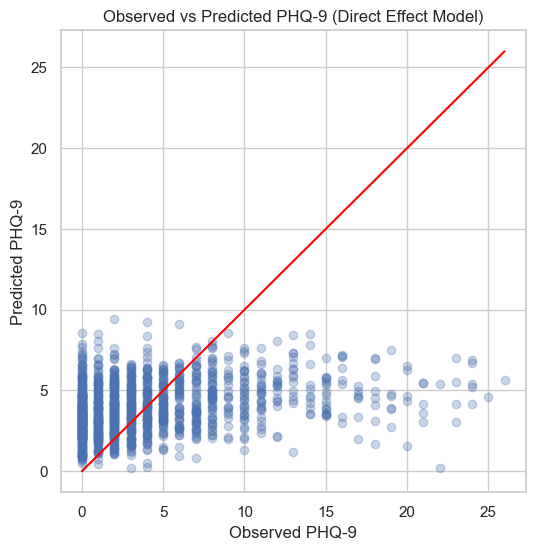

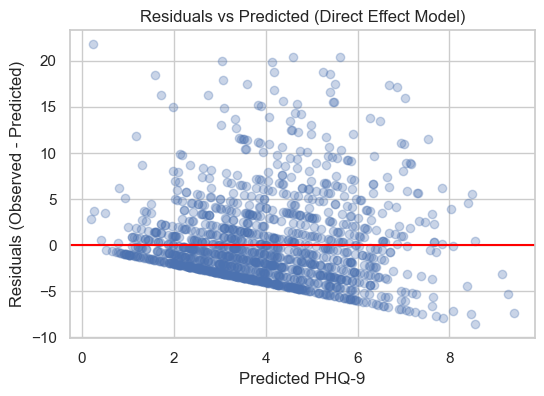

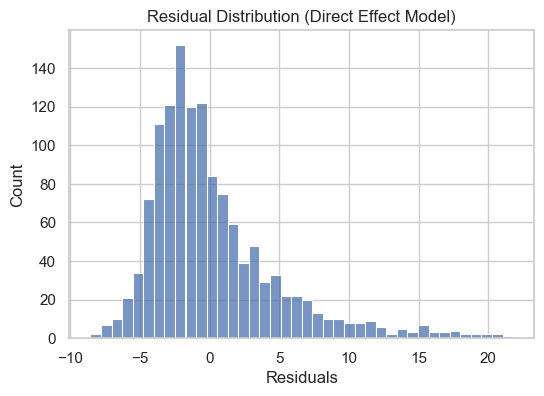


--- Overfit/Underfit Check: TOTAL model ---
Train R^2=0.110 vs Test R^2=0.083
Train RMSE=4.367 vs Test RMSE=4.637
Interpretation: No strong evidence of overfitting; performance is similar across train/test.

--- Overfit/Underfit Check: DIRECT model ---
Train R^2=0.114 vs Test R^2=0.082
Train RMSE=4.357 vs Test RMSE=4.640
Interpretation: No strong evidence of overfitting; performance is similar across train/test.


In [5]:
##Method 1: Linear regression to estimate the direct and total effects of BMI on depression severity as well as the relationship between BMI and CRP. 
##Includes constructing the mediation model paths.
#create model going forwards - start with intercept and add variables one by one to see what affects variance BIC or AIC terms to look up


BMI = "BMXBMI"
CRP = "LBXHSCRP"
PHQ = "phq9_score"

# Pick covariates you actually want in the adjusted models
covars = [
    "age",
    "income_poverty_ratio",
    "sleep_avg",
    "vigorous_activity_minutes",
    # optionally add:
    # "cigarettes_per_day",
    # "moderate_activity_minutes",
    # plus categorical vars as C(gender), C(race_ethnicity) if they’re coded cleanly
]

# Build analysis df
use_cols = [BMI, CRP, PHQ] + covars + ["gender", "race_ethnicity"]
d = df[use_cols].copy()

# Numeric conversion for continuous vars
for c in [BMI, CRP, PHQ] + covars:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# Transform CRP (helps a LOT)
d["logCRP"] = np.log1p(d[CRP])

# Optional nonlinear BMI term (sensitivity)
d["BMI2"] = d[BMI]**2

# Drop missing for models
d_model = d.dropna(subset=[BMI, "logCRP", PHQ] + covars)

# -------------------------
# TOTAL EFFECT (c path)
# -------------------------
formula_total = f"{PHQ} ~ {BMI} + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
m_total = smf.ols(formula_total, data=d_model).fit(cov_type="HC3")

# -------------------------
# MEDIATOR MODEL (a path)
# -------------------------
formula_a = f"logCRP ~ {BMI} + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
m_a = smf.ols(formula_a, data=d_model).fit(cov_type="HC3")

# -------------------------
# DIRECT EFFECT (c') + b path
# -------------------------
formula_direct = f"{PHQ} ~ {BMI} + logCRP + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
m_direct = smf.ols(formula_direct, data=d_model).fit(cov_type="HC3")

print("\nTOTAL EFFECT model (c path):")
print(m_total.summary())

print("\nMEDIATOR model (a path):")
print(m_a.summary())

print("\nDIRECT EFFECT model (c') + b path:")
print(m_direct.summary())

# Effect estimates (on logCRP scale)
a_hat = m_a.params[BMI]
b_hat = m_direct.params["logCRP"]
indirect_ab = a_hat * b_hat
direct_cprime = m_direct.params[BMI]
total_c = m_total.params[BMI]

print("\n--- Effects (point estimates) ---")
print("a (BMI -> logCRP):", a_hat)
print("b (logCRP -> PHQ | BMI):", b_hat)
print("Indirect (a*b):", indirect_ab)
print("Direct (c'):", direct_cprime)
print("Total (c):", total_c)

# -------------------------
# Optional sensitivity: quadratic BMI term
# -------------------------
formula_total_quad = f"{PHQ} ~ {BMI} + BMI2 + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
m_total_quad = smf.ols(formula_total_quad, data=d_model).fit(cov_type="HC3")

print("\nCompare linear vs quadratic total-effect model:")
print("Linear AIC/BIC:", m_total.aic, m_total.bic)
print("Quadratic AIC/BIC:", m_total_quad.aic, m_total_quad.bic)

####Prediction Validation Metrics


# Train test split
train, test = train_test_split(d_model, test_size=0.3, random_state=42)

# Refit model on training
m_train = smf.ols(formula_direct, data=train).fit()

# Predictions
pred = m_train.predict(test)

y_true = test["phq9_score"]

mse = mean_squared_error(y_true, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R^2:", r2)

# =========================
# Model 1 Results Code
# Produces:
# 1) Model comparison table
# 2) Validation metrics (Train/Test MSE, RMSE, R^2)
# 3) Prediction visualizations
# 4) Overfitting/underfitting check (train vs test)
# =========================


sns.set(style="whitegrid")

BMI = "BMXBMI"
CRP = "LBXHSCRP"
PHQ = "phq9_score"

covars = ["age", "income_poverty_ratio", "sleep_avg", "vigorous_activity_minutes"]

use_cols = [BMI, CRP, PHQ] + covars + ["gender", "race_ethnicity"]
d = df[use_cols].copy()

for c in [BMI, CRP, PHQ] + covars:
    d[c] = pd.to_numeric(d[c], errors="coerce")

d["logCRP"] = np.log1p(d[CRP])
d["BMI2"] = d[BMI] ** 2

d_model = d.dropna(subset=[BMI, "logCRP", PHQ] + covars).copy()

formula_total = f"{PHQ} ~ {BMI} + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
formula_a = f"logCRP ~ {BMI} + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
formula_direct = f"{PHQ} ~ {BMI} + logCRP + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"
formula_total_quad = f"{PHQ} ~ {BMI} + BMI2 + " + " + ".join(covars) + " + C(gender) + C(race_ethnicity)"

m_total = smf.ols(formula_total, data=d_model).fit(cov_type="HC3")
m_a = smf.ols(formula_a, data=d_model).fit(cov_type="HC3")
m_direct = smf.ols(formula_direct, data=d_model).fit(cov_type="HC3")
m_total_quad = smf.ols(formula_total_quad, data=d_model).fit(cov_type="HC3")

a_hat = m_a.params[BMI]
b_hat = m_direct.params["logCRP"]
indirect_ab = a_hat * b_hat
direct_cprime = m_direct.params[BMI]
total_c = m_total.params[BMI]
pct_mediated = (indirect_ab / total_c) if total_c != 0 else np.nan

print("\n--- Effects (point estimates) ---")
print(f"a (BMI -> logCRP): {a_hat:.6f}")
print(f"b (logCRP -> PHQ | BMI): {b_hat:.6f}")
print(f"Indirect (a*b): {indirect_ab:.6f}")
print(f"Direct (c'): {direct_cprime:.6f}")
print(f"Total (c): {total_c:.6f}")
print(f"Percent mediated (ab/c): {pct_mediated*100:.1f}%")

print("\nCompare linear vs quadratic total-effect model:")
print("Linear AIC/BIC:", m_total.aic, m_total.bic)
print("Quadratic AIC/BIC:", m_total_quad.aic, m_total_quad.bic)

train, test = train_test_split(d_model, test_size=0.30, random_state=42)

def eval_model(formula, train_df, test_df, y_col):
    m = smf.ols(formula, data=train_df).fit()
    pred_train = m.predict(train_df)
    pred_test = m.predict(test_df)

    y_train = train_df[y_col]
    y_test = test_df[y_col]

    mse_train = mean_squared_error(y_train, pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, pred_train)

    mse_test = mean_squared_error(y_test, pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, pred_test)

    residuals_test = y_test - pred_test

    metrics = {
        "mse_train": mse_train,
        "rmse_train": rmse_train,
        "r2_train": r2_train,
        "mse_test": mse_test,
        "rmse_test": rmse_test,
        "r2_test": r2_test,
    }
    return m, pred_test, residuals_test, metrics

m_total_tr, pred_total_test, resid_total_test, metrics_total = eval_model(formula_total, train, test, PHQ)
m_direct_tr, pred_direct_test, resid_direct_test, metrics_direct = eval_model(formula_direct, train, test, PHQ)

print("\n--- Validation Metrics (Train vs Test) ---")
print("TOTAL model (PHQ ~ BMI + covars):")
print(f"Train: MSE={metrics_total['mse_train']:.3f}, RMSE={metrics_total['rmse_train']:.3f}, R^2={metrics_total['r2_train']:.3f}")
print(f"Test : MSE={metrics_total['mse_test']:.3f}, RMSE={metrics_total['rmse_test']:.3f}, R^2={metrics_total['r2_test']:.3f}")

print("\nDIRECT model (PHQ ~ BMI + logCRP + covars):")
print(f"Train: MSE={metrics_direct['mse_train']:.3f}, RMSE={metrics_direct['rmse_train']:.3f}, R^2={metrics_direct['r2_train']:.3f}")
print(f"Test : MSE={metrics_direct['mse_test']:.3f}, RMSE={metrics_direct['rmse_test']:.3f}, R^2={metrics_direct['r2_test']:.3f}")

comparison = pd.DataFrame([
    {
        "Model": "Mediator (a path)",
        "Outcome": "logCRP",
        "Predictors": "BMI + covariates + gender + race/ethnicity",
        "N": int(m_a.nobs),
        "R2": m_a.rsquared,
        "Adj_R2": m_a.rsquared_adj,
        "AIC": m_a.aic,
        "BIC": m_a.bic,
        "Test_MSE": np.nan,
        "Test_RMSE": np.nan,
        "Test_R2": np.nan
    },
    {
        "Model": "Total effect (c path)",
        "Outcome": "PHQ-9",
        "Predictors": "BMI + covariates + gender + race/ethnicity",
        "N": int(m_total.nobs),
        "R2": m_total.rsquared,
        "Adj_R2": m_total.rsquared_adj,
        "AIC": m_total.aic,
        "BIC": m_total.bic,
        "Test_MSE": metrics_total["mse_test"],
        "Test_RMSE": metrics_total["rmse_test"],
        "Test_R2": metrics_total["r2_test"]
    },
    {
        "Model": "Direct effect (c') + b path",
        "Outcome": "PHQ-9",
        "Predictors": "BMI + logCRP + covariates + gender + race/ethnicity",
        "N": int(m_direct.nobs),
        "R2": m_direct.rsquared,
        "Adj_R2": m_direct.rsquared_adj,
        "AIC": m_direct.aic,
        "BIC": m_direct.bic,
        "Test_MSE": metrics_direct["mse_test"],
        "Test_RMSE": metrics_direct["rmse_test"],
        "Test_R2": metrics_direct["r2_test"]
    },
    {
        "Model": "Total effect (quadratic sensitivity)",
        "Outcome": "PHQ-9",
        "Predictors": "BMI + BMI^2 + covariates + gender + race/ethnicity",
        "N": int(m_total_quad.nobs),
        "R2": m_total_quad.rsquared,
        "Adj_R2": m_total_quad.rsquared_adj,
        "AIC": m_total_quad.aic,
        "BIC": m_total_quad.bic,
        "Test_MSE": np.nan,
        "Test_RMSE": np.nan,
        "Test_R2": np.nan
    },
])

print("\n=== Model Comparison Table ===")
print(comparison.round(4).to_string(index=False))

# Prediction plots (DIRECT model)
y_test = test[PHQ]

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_direct_test, alpha=0.3)
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv], [minv, maxv], color="red")
plt.xlabel("Observed PHQ-9")
plt.ylabel("Predicted PHQ-9")
plt.title("Observed vs Predicted PHQ-9 (Direct Effect Model)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(pred_direct_test, resid_direct_test, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Predicted PHQ-9")
plt.ylabel("Residuals (Observed - Predicted)")
plt.title("Residuals vs Predicted (Direct Effect Model)")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(resid_direct_test, bins=40)
plt.xlabel("Residuals")
plt.title("Residual Distribution (Direct Effect Model)")
plt.show()

def interpret_fit(train_r2, test_r2, train_rmse, test_rmse, label):
    print(f"\n--- Overfit/Underfit Check: {label} ---")
    print(f"Train R^2={train_r2:.3f} vs Test R^2={test_r2:.3f}")
    print(f"Train RMSE={train_rmse:.3f} vs Test RMSE={test_rmse:.3f}")

    r2_gap = train_r2 - test_r2
    rmse_gap = test_rmse - train_rmse

    if (r2_gap > 0.05) or (rmse_gap > 0.5):
        print("Interpretation: Potential overfitting (train performance noticeably better than test).")
    elif (test_r2 < 0.05) and (train_r2 < 0.05):
        print("Interpretation: Likely underfitting (very low explanatory power on both train and test).")
    else:
        print("Interpretation: No strong evidence of overfitting; performance is similar across train/test.")

interpret_fit(metrics_total["r2_train"], metrics_total["r2_test"],
              metrics_total["rmse_train"], metrics_total["rmse_test"],
              "TOTAL model")

interpret_fit(metrics_direct["r2_train"], metrics_direct["r2_test"],
              metrics_direct["rmse_train"], metrics_direct["rmse_test"],
              "DIRECT model")

In [6]:
##Method 2: Mediation Analysis with Bootstrapping will be applied to test the indirect effect and allow us to assess whether CRP significantly mediates 
##the BMI and depression severity relationship.

# =========================
# Method 2: Bootstrap Mediation (a*b) — SMALL TEST RUN + PROGRESS BAR
# After it works, increase B (e.g., 2000 or 5000)
# =========================

# ---- REQUIRED objects from Method 1 ----
# d_model, formula_a, formula_direct, BMI
required = ["d_model", "formula_a", "formula_direct", "BMI"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}. Run Method 1 first.")

# ---- Point estimate from full sample (self-contained) ----
m_a_full = smf.ols(formula_a, data=d_model).fit()
m_b_full = smf.ols(formula_direct, data=d_model).fit()
ab_point = m_a_full.params[BMI] * m_b_full.params["logCRP"]
print(f"Full-sample indirect effect (a*b): {ab_point:.6f}")

# ---- Bootstrap settings ----
B = 5000         

rng = np.random.default_rng(123)
n = len(d_model)
idx = np.arange(n)

boot_ab = np.empty(B, dtype=float)
failures = 0

for i in tqdm(range(B), desc="Bootstrapping a*b", leave=True):
    sample_idx = rng.choice(idx, size=n, replace=True)
    bs = d_model.iloc[sample_idx]

    try:
        m_a_bs = smf.ols(formula_a, data=bs).fit()
        m_b_bs = smf.ols(formula_direct, data=bs).fit()
        boot_ab[i] = m_a_bs.params[BMI] * m_b_bs.params["logCRP"]
    except Exception:
        boot_ab[i] = np.nan
        failures += 1

# drop failed iterations (if any)
boot_ab = boot_ab[~np.isnan(boot_ab)]
if len(boot_ab) < B:
    print(f"Note: {B - len(boot_ab)} iterations failed and were excluded. Failures={failures}")

# CI + p-like summary
ci_low, ci_high = np.percentile(boot_ab, [2.5, 97.5])
p_boot = 2 * min(np.mean(boot_ab <= 0), np.mean(boot_ab >= 0))

print("\nBOOTSTRAPPED INDIRECT EFFECT (a*b):")
print(f"Point estimate: {ab_point:.6f}")
print(f"95% percentile CI: ({ci_low:.6f}, {ci_high:.6f})")
print(f"Approx. two-sided bootstrap p: {p_boot:.4f}")
print(f"Effective bootstrap samples used: {len(boot_ab)}")

Full-sample indirect effect (a*b): 0.018077


Bootstrapping a*b:   0%|          | 0/5000 [00:00<?, ?it/s]


BOOTSTRAPPED INDIRECT EFFECT (a*b):
Point estimate: 0.018077
95% percentile CI: (0.006785, 0.029185)
Approx. two-sided bootstrap p: 0.0008
Effective bootstrap samples used: 5000


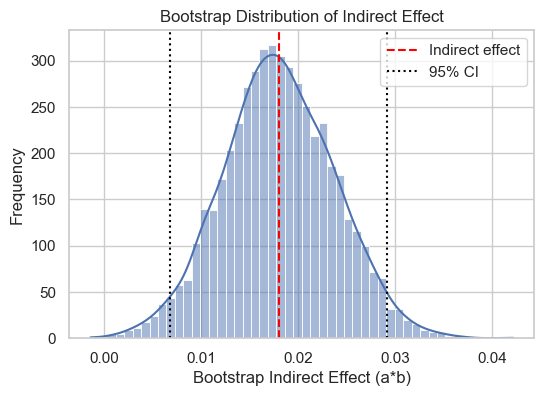

In [7]:
plt.figure(figsize=(6,4))

sns.histplot(boot_ab, bins=50, kde=True)

plt.axvline(ab_point, color="red", linestyle="--", label="Indirect effect")

plt.axvline(ci_low, color="black", linestyle=":", label="95% CI")
plt.axvline(ci_high, color="black", linestyle=":")

plt.xlabel("Bootstrap Indirect Effect (a*b)")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Indirect Effect")

plt.legend()
plt.show()

In [8]:
# ----------------------------------------------------
# Import data
# ----------------------------------------------------

NHdata_clean = NHdata_OG.copy()


# ----------------------------------------------------
# Drop unnecessary columns
# ----------------------------------------------------

columns_to_keep = [
    # Demographics
    "age",
    "gender",
    "race_ethnicity",
    "household_size",
    "income_poverty_ratio",
    
    # Sleep
    "sleep_weekend",
    "sleep_weekday",
    "sleep_avg",
    
    # Depression
    "phq9_score",
    "is_depressed",
    "phq9_severity",
    
    # Inflammation
    "crp",
    
    # BMI
    "bmi",
   
    # Physical Activity
    "vigorous_activity_minutes",
    "vigorous_activity_category",

    # Occupation
    "employment_status"
]

NHdata_clean = NHdata_clean[columns_to_keep]


# ----------------------------------------------------
# Fixing missing value in phq9_severity
# ----------------------------------------------------

mask = NHdata_clean["phq9_severity"].isna()

NHdata_clean.loc[mask, "phq9_severity"] = pd.cut(
    NHdata_clean.loc[mask, "phq9_score"],
    bins=[-1, 4, 9, 14, 27],
    labels=["None", "Mild", "Moderate", "Severe"]
)

## Regression Tree (BMI)


In [9]:
# ----------------------------------------------------
# Drop missing outcomes
# ----------------------------------------------------

NHdata = NHdata_clean.dropna(subset=["bmi"])

# ----------------------------------------------------
# Define X and y
# ----------------------------------------------------

y = NHdata["bmi"]
X = NHdata.drop(columns=["bmi", "phq9_severity", "is_depressed"])

# ----------------------------------------------------
# Encode all categorical variables
# ----------------------------------------------------

categorical_cols = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ----------------------------------------------------
# Drop remaining missing values in X
# ----------------------------------------------------

data_complete = pd.concat([X, y], axis=1).dropna()

X = data_complete.drop(columns=["bmi"])
y = data_complete["bmi"]

# ----------------------------------------------------
# Train/Test Split (clean + aligned)
# ----------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

In [10]:
# ----------------------------------------------------
# Fit Random Forest
# ----------------------------------------------------

rf = RandomForestRegressor(
    random_state=1,
    n_estimators=500,   # number of trees
    n_jobs=-1           # use all cores
)

# Optional hyperparameter tuning
param_grid = {
    'max_features': ['sqrt', 'log2', 0.5],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

kfold = skm.KFold(n_splits=5,
                  shuffle=True,
                  random_state=10)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

# ----------------------------------------------------
# Comparison Metrics
# ----------------------------------------------------

y_pred_rf = best_rf.predict(X_test)
y_pred_train = best_rf.predict(X_train)

mse_rf_bmi = mean_squared_error(y_test, y_pred_rf)
train_mse = mean_squared_error(y_train, y_pred_train)

train_rmse = np.sqrt(train_mse)
rmse_rf_bmi = np.sqrt(mse_rf_bmi)

train_r2 = r2_score(y_train, y_pred_train)
r2_rf_bmi = r2_score(y_test, y_pred_rf)


print("Test MSE:", mse_rf_bmi)
print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Test RMSE:", rmse_rf_bmi)
print("Train R²:", train_r2)
print("Test R²:", r2_rf_bmi)
#print("Best parameters: ", grid_rf.best_params_)



Test MSE: 40.977051807614515
Train MSE: 24.909078715847606
Train RMSE: 4.990899589838249
Test RMSE: 6.401332033851588
Train R²: 0.5040568061718936
Test R²: 0.27359734803701985


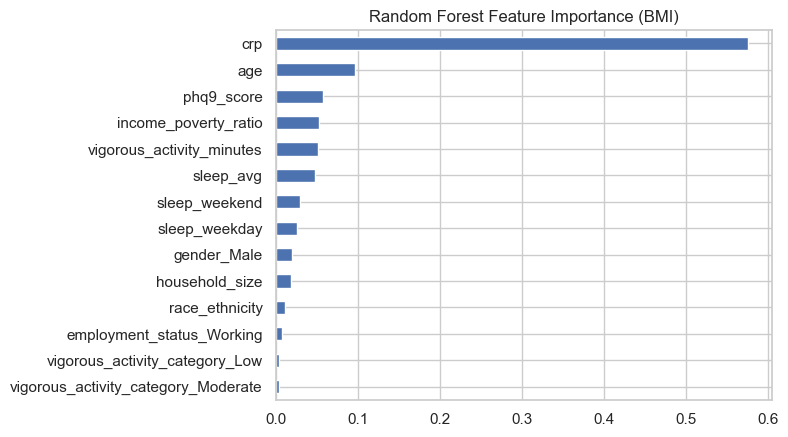

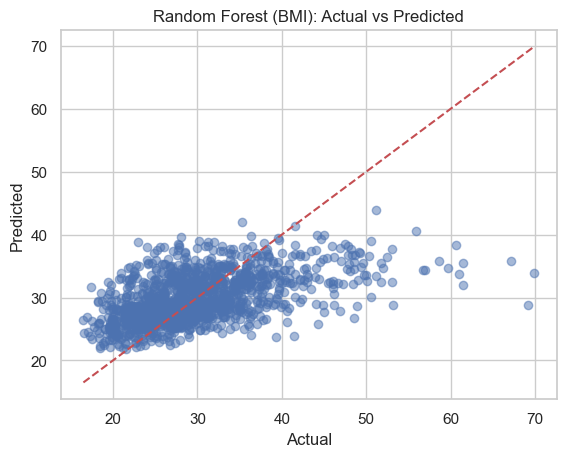

In [11]:
# ----------------------------------------------------
# Single Sample Tree
# ----------------------------------------------------
# single_tree = best_rf.estimators_[0]

# plt.figure(figsize=(18, 10))
# plot_tree(
#     single_tree,
#     feature_names=X_train.columns,
#     filled=True,
#     rounded=True,
#     fontsize=8
# )
# plt.show()

# ----------------------------------------------------
# Feature Importance Plot
# ----------------------------------------------------

importances = best_rf.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns)

feat_importances.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance (BMI)")
plt.show()

# ----------------------------------------------------
# Prediction Plot
# ----------------------------------------------------

plt.figure()
plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest (BMI): Actual vs Predicted")
plt.show()


## Regression Tree (CRP)

In [12]:
# ----------------------------------------------------
# Drop missing outcomes
# ----------------------------------------------------

NHdata = NHdata_clean.dropna(subset=["crp"])

# ----------------------------------------------------
# Define X and y
# ----------------------------------------------------

y = NHdata["crp"]
X = NHdata.drop(columns=["crp", "phq9_severity", "is_depressed"])

# ----------------------------------------------------
# Encode all categorical variables
# ----------------------------------------------------

categorical_cols = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ----------------------------------------------------
# Drop remaining missing values in X
# ----------------------------------------------------

data_complete = pd.concat([X, y], axis=1).dropna()

X = data_complete.drop(columns=["crp"])
y = data_complete["crp"]

# ----------------------------------------------------
# Train/Test Split (clean + aligned)
# ----------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

In [13]:
# ----------------------------------------------------
# Fit Random Forest
# ----------------------------------------------------

rf = RandomForestRegressor(
    random_state=1,
    n_estimators=500,   # number of trees
    n_jobs=-1           # use all cores
)

# Optional hyperparameter tuning
param_grid = {
    'max_features': ['sqrt', 'log2', 0.5],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

kfold = skm.KFold(n_splits=5,
                  shuffle=True,
                  random_state=10)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

# ----------------------------------------------------
# Evaluate Random Forest
# ----------------------------------------------------

y_pred_rf = best_rf.predict(X_test)
y_pred_train = best_rf.predict(X_train)

train_mse = mean_squared_error(y_train, y_pred_train)
mse_rf_crp = mean_squared_error(y_test, y_pred_rf)

train_rmse = np.sqrt(train_mse)
rmse_rf_crp = np.sqrt(mse_rf_crp)

train_r2 = r2_score(y_train, y_pred_train)
r2_rf_crp = r2_score(y_test, y_pred_rf)



print("Test MSE:", mse_rf_crp)
print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Test RMSE:", rmse_rf_crp)
print("Train R²:", train_r2)
print("Test R²:", r2_rf_crp)
#print("Best parameters: ", grid_rf.best_params_)




Test MSE: 63.7593809134098
Train MSE: 34.74465760767215
Train RMSE: 5.894459908055373
Test RMSE: 7.9849471453109695
Train R²: 0.29321089861525895
Test R²: 0.08620846179971631


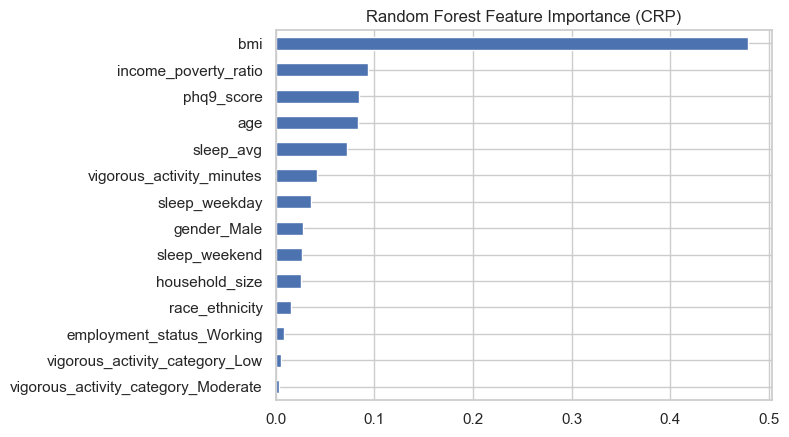

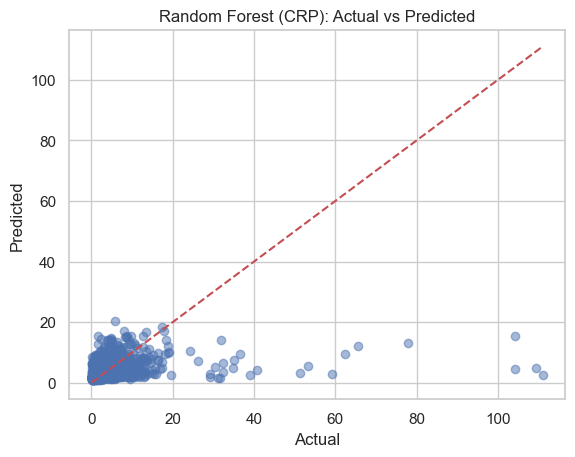

In [14]:
# ----------------------------------------------------
# Single Sample Tree
# ----------------------------------------------------
# single_tree = best_rf.estimators_[0]

# plt.figure(figsize=(18, 10))
# plot_tree(
#     single_tree,
#     feature_names=X_train.columns,
#     filled=True,
#     rounded=True,
#     fontsize=8
# )
# plt.show()

# ----------------------------------------------------
# Feature Importance Plot
# ----------------------------------------------------

importances = best_rf.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns)

feat_importances.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance (CRP)")
plt.show()




# ----------------------------------------------------
# Prediction Plot
# ----------------------------------------------------

plt.figure()
plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest (CRP): Actual vs Predicted")
plt.show()


## Regression tree (phq9_score)

In [15]:
# ----------------------------------------------------
# Drop missing outcomes
# ----------------------------------------------------

NHdata = NHdata_clean.dropna(subset=["phq9_score"])

# ----------------------------------------------------
# Define X and y
# ----------------------------------------------------

y = NHdata["phq9_score"]
X = NHdata.drop(columns=["phq9_score", "phq9_severity", "is_depressed"])

# ----------------------------------------------------
# Encode all categorical variables
# ----------------------------------------------------

categorical_cols = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ----------------------------------------------------
# Drop remaining missing values in X
# ----------------------------------------------------

data_complete = pd.concat([X, y], axis=1).dropna()

X = data_complete.drop(columns=["phq9_score"])
y = data_complete["phq9_score"]

# ----------------------------------------------------
# Train/Test Split (clean + aligned)
# ----------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

In [16]:
# ----------------------------------------------------
# Fit Random Forest
# ----------------------------------------------------

rf = RandomForestRegressor(
    random_state=1,
    n_estimators=500,   # number of trees
    n_jobs=-1           # use all cores
)

# Optional hyperparameter tuning
param_grid = {
    'max_features': ['sqrt', 'log2', 0.5],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

kfold = skm.KFold(n_splits=5,
                  shuffle=True,
                  random_state=10)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

# ----------------------------------------------------
# Evaluate Random Forest
# ----------------------------------------------------

y_pred_rf = best_rf.predict(X_test)
y_pred_train = best_rf.predict(X_train)

train_mse = mean_squared_error(y_train, y_pred_train)
mse_rf_phq9 = mean_squared_error(y_test, y_pred_rf)

train_rmse = np.sqrt(train_mse)
rmse_rf_phq9 = np.sqrt(mse_rf_phq9)

train_r2 = r2_score(y_train, y_pred_train)
r2_rf_phq9 = r2_score(y_test, y_pred_rf)


# print("Test MSE:", mse_rf_phq9)
# print("Train MSE:", train_mse)
# print("Train RMSE:", train_rmse)
# print("Test RMSE:", rmse_rf_phq9)
# print("Train R²:", train_r2)
# print("Test R²:", r2_rf_phq9)
print("Best parameters: ", grid_rf.best_params_)






Best parameters:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5}


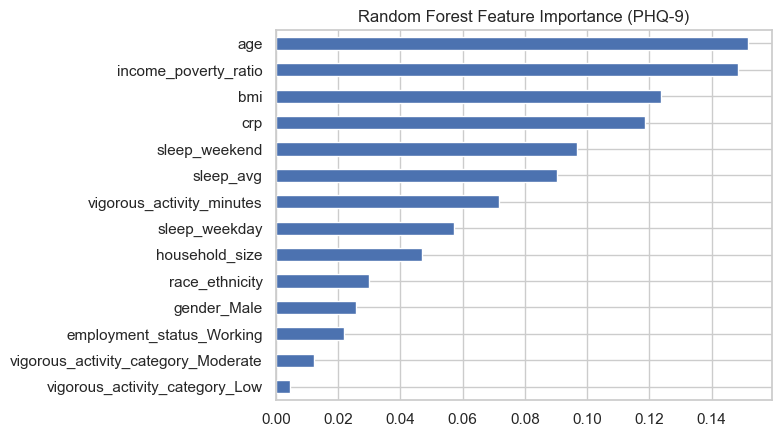

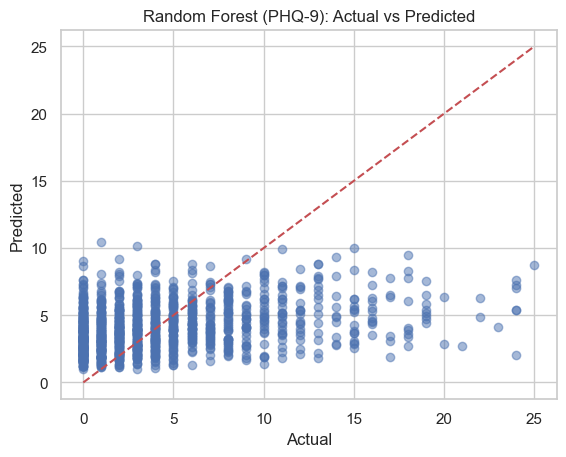

In [17]:
# ----------------------------------------------------
# Single Sample Tree
# ----------------------------------------------------
# single_tree = best_rf.estimators_[0]

# plt.figure(figsize=(18, 10))
# plot_tree(
#     single_tree,
#     feature_names=X_train.columns,
#     filled=True,
#     rounded=True,
#     fontsize=8
# )
# plt.show()

# ----------------------------------------------------
# Feature Importance Plot
# ----------------------------------------------------

importances = best_rf.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns)

feat_importances.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance (PHQ-9)")
plt.show()



# ----------------------------------------------------
# Prediction Plot
# ----------------------------------------------------

plt.figure()
plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest (PHQ-9): Actual vs Predicted")
plt.show()

# Generalized Additive Model (New)

Path a Test MSE: 38.4559051388687
Path a Test R2: 0.06821403999274245


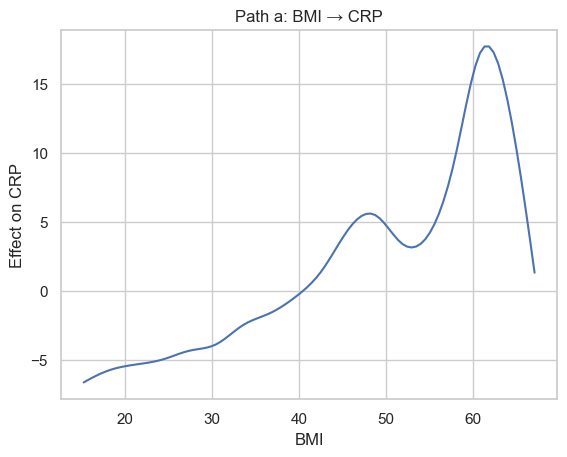

Total Effect Test MSE: 22.734663682743083
Total Effect Test R2: -0.010147181996770893


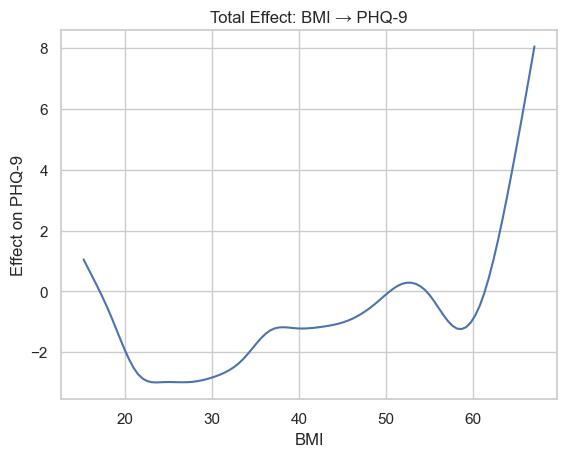

Full Model Test MSE: 22.65470871685885
Full Model Test R2: -0.006594620824031283
Full Model smoothing penalty:  [[0.6], [0.6]]


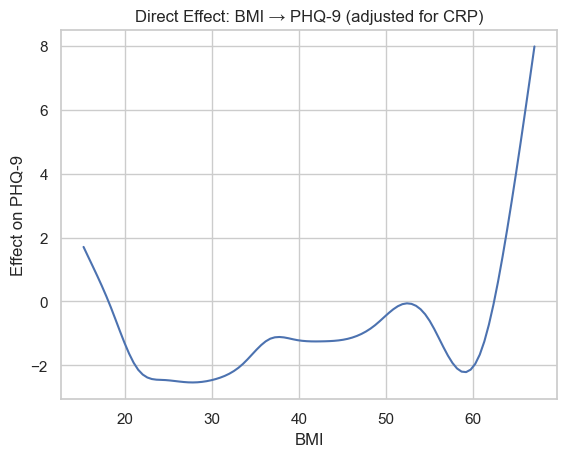

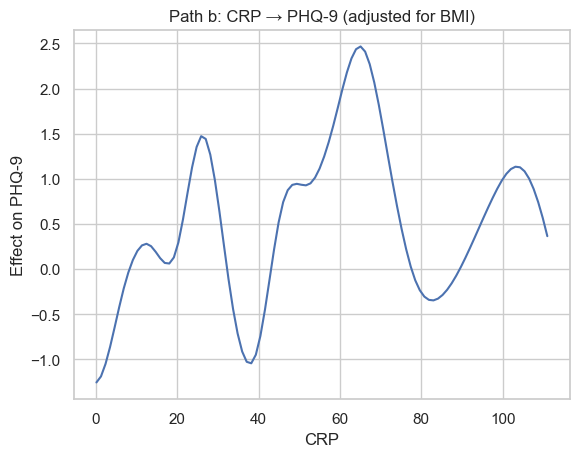

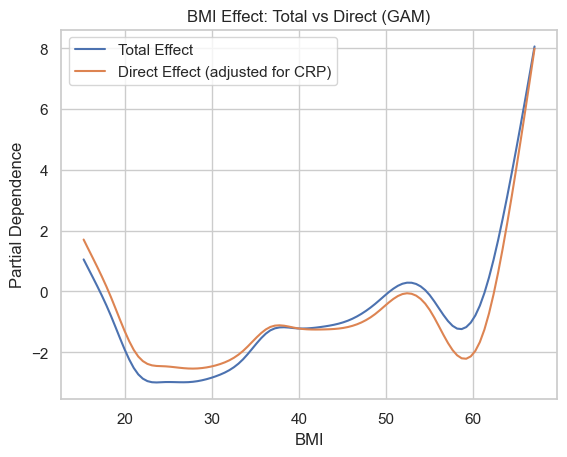

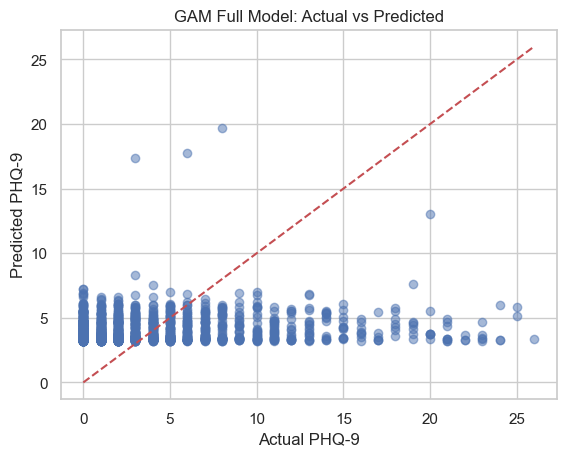

Training MSE: 20.846482168069848
Training RMSE: 4.56579480135385
Training R²: 0.040814503160060744


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ----------------------------------------------------
# Prepare Data
# ----------------------------------------------------

# Drop missing outcome
NHdata = NHdata_clean.dropna(subset=["phq9_score"])

# Select variables of interest
NHdata = NHdata[["bmi", "crp", "phq9_score"]].dropna()

# Define predictors and outcome
X = NHdata[["bmi", "crp"]]
y = NHdata["phq9_score"]

# ----------------------------------------------------
# Train/Test Split (70/30)
# ----------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

# Convert to numpy
bmi_train = X_train["bmi"].values.reshape(-1, 1)
crp_train = X_train["crp"].values
phq_train = y_train.values

bmi_test = X_test["bmi"].values.reshape(-1, 1)
crp_test = X_test["crp"].values
phq_test = y_test.values

X_full_train = X_train[["bmi", "crp"]].values
X_full_test = X_test[["bmi", "crp"]].values

# ====================================================
# MODEL 1: Path a  (BMI → CRP)
# ====================================================

gam_a = LinearGAM(s(0)).fit(bmi_train, crp_train)

# Evaluate on test set
crp_pred = gam_a.predict(bmi_test)
print("Path a Test MSE:", mean_squared_error(crp_test, crp_pred))
print("Path a Test R2:", r2_score(crp_test, crp_pred))

# Plot Path a
XX = gam_a.generate_X_grid(term=0)
plt.figure()
plt.plot(XX[:, 0], gam_a.partial_dependence(term=0, X=XX))
plt.title("Path a: BMI → CRP")
plt.xlabel("BMI")
plt.ylabel("Effect on CRP")
plt.show()

# ====================================================
# MODEL 2: Total Effect (Path c)  BMI → PHQ-9
# ====================================================

gam_total = LinearGAM(s(0)).fit(bmi_train, phq_train)

# Evaluate
phq_pred_total = gam_total.predict(bmi_test)
print("Total Effect Test MSE:", mean_squared_error(phq_test, phq_pred_total))
print("Total Effect Test R2:", r2_score(phq_test, phq_pred_total))

# Plot Total Effect
XX = gam_total.generate_X_grid(term=0)
plt.figure()
plt.plot(XX[:, 0], gam_total.partial_dependence(term=0, X=XX))
plt.title("Total Effect: BMI → PHQ-9")
plt.xlabel("BMI")
plt.ylabel("Effect on PHQ-9")
plt.show()

# ====================================================
# MODEL 3: Direct + Mediator Model (Paths b and c′)
# PHQ-9 ~ s(BMI) + s(CRP)
# ====================================================

gam_full = LinearGAM(s(0) + s(1)).fit(X_full_train, phq_train)

# Evaluate
phq_pred_full = gam_full.predict(X_full_test)
print("Full Model Test MSE:", mean_squared_error(phq_test, phq_pred_full))
print("Full Model Test R2:", r2_score(phq_test, phq_pred_full))

print("Full Model smoothing penalty: ", gam_full.lam)

# Plot Direct Effect (BMI adjusted for CRP)
XX_bmi = gam_full.generate_X_grid(term=0)
plt.figure()
plt.plot(XX_bmi[:, 0], gam_full.partial_dependence(term=0, X=XX_bmi))
plt.title("Direct Effect: BMI → PHQ-9 (adjusted for CRP)")
plt.xlabel("BMI")
plt.ylabel("Effect on PHQ-9")
plt.show()

# Plot Path b (CRP → PHQ-9 adjusted for BMI)
XX_crp = gam_full.generate_X_grid(term=1)
plt.figure()
plt.plot(XX_crp[:, 1], gam_full.partial_dependence(term=1, X=XX_crp))
plt.title("Path b: CRP → PHQ-9 (adjusted for BMI)")
plt.xlabel("CRP")
plt.ylabel("Effect on PHQ-9")
plt.show()

# ====================================================
# Overlay Total vs Direct BMI Effect
# ====================================================

# Generate grid from each model separately
XX_total = gam_total.generate_X_grid(term=0)
XX_full = gam_full.generate_X_grid(term=0)

plt.figure()

plt.plot(
    XX_total[:, 0],
    gam_total.partial_dependence(term=0, X=XX_total),
    label="Total Effect"
)

plt.plot(
    XX_full[:, 0],
    gam_full.partial_dependence(term=0, X=XX_full),
    label="Direct Effect (adjusted for CRP)" # CRP held constant
)

plt.legend()
plt.title("BMI Effect: Total vs Direct (GAM)")
plt.xlabel("BMI")
plt.ylabel("Partial Dependence")
plt.show()

# ====================================================
# Actual vs Predicted (Full Model)
# ====================================================

plt.figure()
plt.scatter(phq_test, phq_pred_full, alpha=0.5)
plt.plot(
    [phq_test.min(), phq_test.max()],
    [phq_test.min(), phq_test.max()],
    'r--'
)
plt.xlabel("Actual PHQ-9")
plt.ylabel("Predicted PHQ-9")
plt.title("GAM Full Model: Actual vs Predicted")
plt.show()



# ----------------------------------------------------
# Comparison Table Metrics
# ----------------------------------------------------

# Path a (BMI → CRP)
gam_mse_a = mean_squared_error(crp_test, crp_pred)
gam_rmse_a = np.sqrt(gam_mse_a)
gam_r2_a = r2_score(crp_test, crp_pred)

# Total Effect (BMI → PHQ9)
gam_mse_total = mean_squared_error(phq_test, phq_pred_total)
gam_rmse_total = np.sqrt(gam_mse_total)
gam_r2_total = r2_score(phq_test, phq_pred_total)

# Full Model (BMI + CRP → PHQ9)
gam_mse_full = mean_squared_error(phq_test, phq_pred_full)
gam_rmse_full = np.sqrt(gam_mse_full)
gam_r2_full = r2_score(phq_test, phq_pred_full)



# Training stats
phq_pred_train = gam_full.predict(X_full_train)

train_mse = mean_squared_error(phq_train, phq_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(phq_train, phq_pred_train)

print("Training MSE:", train_mse)
print("Training RMSE:", train_rmse)
print("Training R²:", train_r2)


# Model Comparison Tables

In [19]:
# ====================================================
# All Model Comparison (Linear, RF, GAM)
# ====================================================

full_comparison_table = pd.DataFrame({
    "Model": ["Random Forest (BMI)", "Random Forest (CRP)", "Random Forest (PHQ-9)", "GAM"],
    "MSE": [mse_rf_bmi, mse_rf_crp, mse_rf_phq9, gam_mse_full],
    "RMSE": [rmse_rf_bmi, rmse_rf_crp, rmse_rf_phq9, gam_rmse_full],
    "R2": [r2_rf_bmi, r2_rf_crp, r2_rf_phq9, gam_r2_full]
})


print("\nModel Comparison Table:\n")
print(full_comparison_table)


# ====================================================
# GAM Comparison (Mediation Support)
# ====================================================

gam_comparison_table = pd.DataFrame({
    "Model": [
        "Path a (BMI → CRP)",
        "Total Effect (BMI → PHQ9)",
        "Full Model (BMI + CRP → PHQ9)"
    ],
    "Test MSE": [gam_mse_a, gam_mse_total, gam_mse_full],
    "Test RMSE": [gam_rmse_a, gam_rmse_total, gam_rmse_full],
    "Test R2": [gam_r2_a, gam_r2_total, gam_r2_full]
})

print("\nGAM Model Comparison Table:\n")
print(gam_comparison_table)


Model Comparison Table:

                   Model        MSE      RMSE        R2
0    Random Forest (BMI)  40.977052  6.401332  0.273597
1    Random Forest (CRP)  63.759381  7.984947  0.086208
2  Random Forest (PHQ-9)  19.111531  4.371674  0.105127
3                    GAM  22.654709  4.759696 -0.006595

GAM Model Comparison Table:

                           Model   Test MSE  Test RMSE   Test R2
0             Path a (BMI → CRP)  38.455905   6.201283  0.068214
1      Total Effect (BMI → PHQ9)  22.734664   4.768088 -0.010147
2  Full Model (BMI + CRP → PHQ9)  22.654709   4.759696 -0.006595
